In [113]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("data", exist_ok=True)

In [114]:
CONFIDENCE_1 = 0.95
CONFIDENCE_2 = 0.99
TRADING_DAYS = 252

START = "2020-02-20"
END = "2020-05-11"

In [115]:
portfolio = pd.read_csv("data/portfolio_returns_log.csv", index_col=0, parse_dates=True)
asset_returns = pd.read_csv("data/returns_log.csv", index_col="Date", parse_dates=True)
prices = pd.read_csv("data/prices.csv", index_col=0, parse_dates=True)
#print(portfolio)

#print(weight)


In [116]:
# ---  First scenario : Historic case ---
if isinstance(portfolio, pd.DataFrame):
    portfolio = portfolio.iloc[:, 0]  
    
covid_portfolio = portfolio.loc[START:END].dropna()
print(f"Covid window: {START} -> {END} ({len(covid_portfolio)} jours)")
#print(covid_portfolio.describe())

cum_return = np.exp(covid_portfolio.sum()) - 1
print("Cumulative return:", f"{cum_return:.2%}")

Covid window: 2020-02-20 -> 2020-05-11 (58 jours)
Cumulative return: -15.43%


              S&P500    EUROSTOXX     EUR_BOND       EURUSD   GOLD
Date                                                              
2020-03-02  1.105131  1592.300049  3090.229980  3338.830078  1.088
2020-03-03  1.114405  1642.099976  3003.370117  3371.969971  1.010
2020-03-04  1.118068  1641.099976  3130.120117  3420.560059  0.992
2020-03-05  1.113908  1666.400024  3023.939941  3363.580078  0.926
2020-03-06  1.122385  1670.800049  2972.370117  3232.070068  0.706
2020-03-09  1.138602  1674.500000  2746.560059  2959.070068  0.499
2020-03-10  1.139796  1659.099976  2882.229980  2910.020020  0.748
2020-03-11  1.131651  1641.400024  2741.379883  2905.560059  0.820
2020-03-12  1.126152  1589.300049  2480.639893  2545.229980  0.849
2020-03-13  1.118493  1515.699951  2711.020020  2586.020020  0.951
2020-03-16  1.115536  1485.900024  2386.129883  2450.370117  0.728
2020-03-17  1.116321  1524.900024  2529.189941  2530.500000  0.997
2020-03-18  1.101552  1477.300049  2398.100098  2385.820068  1

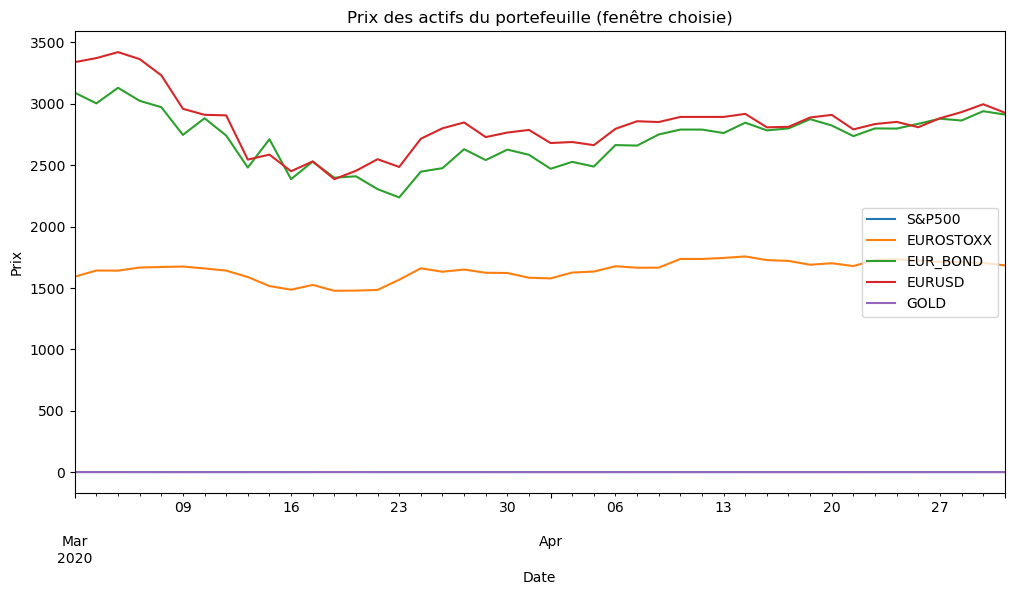

In [117]:
# nouvelle fenêtre d’analyse
START = "2020-03-01"   # date de début souhaitée
END   = "2020-04-30"   # date de fin souhaitée

# afficher les prix des actifs du portefeuille sur la fenêtre choisie
asset_prices_window = prices.loc[START:END]
print(asset_prices_window)
asset_prices_window.plot(figsize=(12, 6))
plt.title("Prix des actifs du portefeuille (fenêtre choisie)")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.legend(loc="best")
plt.show()
# …et, si besoin, recalculez la VaR/ES, les drawdowns, etc. avec ces nouvelles bornes


In [118]:

covid_var_95 = np.percentile(covid_portfolio, (1 - CONFIDENCE_1) * 100)
covid_var_99 = np.percentile(covid_portfolio, (1 - CONFIDENCE_2) * 100)
covid_es_95 = covid_portfolio[covid_portfolio <= covid_var_95].mean()

print("Covid VaR 95%:", f"{covid_var_95:.2%}")
print("Covid VaR 99%:", f"{covid_var_99:.2%}")
print("Covid ES 95%:", f"{covid_es_95:.2%}")

Covid VaR 95%: -4.15%
Covid VaR 99%: -7.60%
Covid ES 95%: -7.12%


In [119]:
# max drawdown
port_cum = np.exp(portfolio.cumsum()) 
max_drawdown = -(port_cum / port_cum.cummax() - 1).min()
print("Max drawdown:", f"{max_drawdown:.2%}")

Max drawdown: 25.87%


In [120]:
#worst day
worst_day = portfolio.idxmin()
worst_return = portfolio.min()
print("Worst day:", worst_day.date()) # lockdown
print("Worst  return:", f"{worst_return:.2%}")

Worst day: 2020-03-16
Worst  return: -8.03%
